# NeuroQWERTY v2 + PSO feature selection

Ce notebook complète `04_keyboard_dynamics_neuroqwerty_v2_segments.ipynb`.

Objectif : vérifier si la sélection de features par PSO améliore ou simplifie la méthode segmentée actuellement utilisée par l'application clavier.

On compare quatre variantes :

1. **All features** : baseline v2 actuelle avec toutes les features numériques.
2. **Timing-only** : retrait manuel des features dépendantes du layout clavier.
3. **PSO all features** : PSO sur toutes les features.
4. **PSO timing-only** : PSO uniquement sur les features temporelles.

La validation reste groupée par sujet (`pID`) pour éviter la fuite de données entre train et validation.


In [1]:
from pathlib import Path
import re
import warnings

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pyswarms.discrete import BinaryPSO
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if not (ROOT / "data" / "neuroqwerty-mit-csxpd-dataset-1.0.0").exists() and ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_ROOT = ROOT / "data" / "neuroqwerty-mit-csxpd-dataset-1.0.0"
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
print(ROOT)


/home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection


## 1. Chargement et nettoyage

On reprend le loader simple du notebook v2. Le loader legacy `nqDataLoader.py` n'est pas utilisé directement.


In [2]:
KEY_COLUMNS = ["key", "hold_time", "release_time", "press_time"]
MOUSE_RE = re.compile(r'"?mouse.+"?', re.I)
LONG_META_RE = re.compile(r'"?(Shift.+|Alt.+|Control.+)"?', re.I)
BACKSPACE_RE = re.compile(r'"?BackSpace"?', re.I)
PUNCT_OR_SPACE_RE = re.compile(r'"?(space|comma|period|semicolon|slash|minus|equal|apostrophe|Return)"?', re.I)
LEFT_KEYS = set("qwertasdfgzxcvb")
RIGHT_KEYS = set("yuiophjklnm")


def load_raw(path):
    df = pd.read_csv(path, header=None, names=KEY_COLUMNS)
    df["key"] = df["key"].astype(str).str.strip().str.replace('"', "", regex=False)
    for column in ["hold_time", "release_time", "press_time"]:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    return df


def clean(df):
    d = df.dropna(subset=["hold_time", "release_time", "press_time"]).copy()
    k = d["key"].astype(str)
    keep = ~k.str.match(MOUSE_RE) & ~k.str.match(LONG_META_RE) & ~k.str.match(BACKSPACE_RE)
    d = d.loc[keep]
    d = d[(d.press_time > 0) & (d.release_time > 0) & (d.hold_time.between(0, 5))]
    d = d.sort_values("press_time").reset_index(drop=True)
    d["flight_time"] = d.press_time.diff()
    d.loc[d.flight_time < 0, "flight_time"] = np.nan
    d["is_space_punct"] = d.key.str.match(PUNCT_OR_SPACE_RE).astype(int)
    d["hand_left"] = d.key.str.lower().str[:1].isin(LEFT_KEYS).astype(int)
    d["hand_right"] = d.key.str.lower().str[:1].isin(RIGHT_KEYS).astype(int)
    d["hand_switch"] = (d.hand_left.diff().abs().fillna(0) > 0).astype(int)
    return d


def load_sessions():
    rows = []
    raws = {}
    for dataset in ["MIT-CS1PD", "MIT-CS2PD"]:
        gt = pd.read_csv(DATA_ROOT / dataset / f"GT_DataPD_{dataset}.csv")
        raw_dir = DATA_ROOT / dataset / f"data_{dataset}"
        for _, subject in gt.iterrows():
            for file_col in [column for column in gt.columns if column.startswith("file_")]:
                filename = subject.get(file_col)
                if pd.isna(filename) or not str(filename).strip():
                    continue
                session_uid = f"{dataset}_{int(subject.pID)}_{file_col}"
                raw_path = raw_dir / str(filename)
                cleaned = clean(load_raw(raw_path))
                raws[session_uid] = cleaned
                rows.append({
                    "session_uid": session_uid,
                    "dataset": dataset,
                    "pID": int(subject.pID),
                    "session_file": str(filename),
                    "session_id": file_col,
                    "label": int(bool(subject["gt"])),
                    "n_keys": len(cleaned),
                })
    return pd.DataFrame(rows), raws


sessions, raw_sessions = load_sessions()
print("sessions", len(sessions), "subjects", sessions.pID.nunique())
display(sessions.groupby("label").agg(sessions=("label", "size"), subjects=("pID", "nunique")))


sessions 116 subjects 85


,sessions,subjects
label,,
0,56,43
1,60,42


## 2. Features segmentées

On utilise ici des segments complets de 300 frappes (`min_len=300`) pour coller au protocole navigateur actuel. Le notebook v2 initial acceptait aussi des segments partiels à partir de 120 frappes; cette expérience est donc volontairement plus stricte.


In [3]:
def safe_div(a, b):
    return np.nan if b is None or pd.isna(b) or abs(b) < 1e-12 else a / b


def entropy_binary(p):
    if pd.isna(p) or p <= 0 or p >= 1:
        return 0.0
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))


def agg_features(d):
    hold = d.hold_time.dropna()
    flight = d.flight_time.dropna()
    duration = d.release_time.max() - d.press_time.min() if len(d) else np.nan
    out = {
        "n_keystrokes": len(d),
        "duration_sec": duration,
        "keys_per_min": safe_div(len(d) * 60, duration),
        "mean_hold": hold.mean(),
        "std_hold": hold.std(),
        "median_hold": hold.median(),
        "iqr_hold": hold.quantile(0.75) - hold.quantile(0.25),
        "q10_hold": hold.quantile(0.1),
        "q90_hold": hold.quantile(0.9),
        "skew_hold": hold.skew(),
        "kurt_hold": hold.kurt(),
        "cv_hold": safe_div(hold.std(), hold.mean()),
        "mean_flight": flight.mean(),
        "std_flight": flight.std(),
        "median_flight": flight.median(),
        "iqr_flight": flight.quantile(0.75) - flight.quantile(0.25),
        "q10_flight": flight.quantile(0.1),
        "q90_flight": flight.quantile(0.9),
        "skew_flight": flight.skew(),
        "kurt_flight": flight.kurt(),
        "cv_flight": safe_div(flight.std(), flight.mean()),
        "hold_to_flight": safe_div(hold.mean(), flight.mean()),
        "long_hold_rate": (hold > hold.quantile(0.9)).mean() if len(hold) > 5 else np.nan,
        "long_flight_rate": (flight > 1.0).mean() if len(flight) > 5 else np.nan,
        "space_punct_rate": d.is_space_punct.mean(),
        "left_rate": d.hand_left.mean(),
        "right_rate": d.hand_right.mean(),
        "hand_switch_rate": d.hand_switch.mean(),
    }
    out["hand_entropy"] = entropy_binary(out["left_rate"])
    return out


def build_segment_features(window=300, stride=150, min_len=300):
    rows = []
    for _, session in sessions.iterrows():
        d = raw_sessions[session.session_uid]
        starts = list(range(0, max(len(d) - min_len + 1, 0), stride))
        for segment_id, start in enumerate(starts):
            segment = d.iloc[start:min(start + window, len(d))]
            if len(segment) < min_len:
                continue
            rows.append({
                **session.to_dict(),
                "segment_id": segment_id,
                "segment_start": start,
                "segment_len": len(segment),
                **agg_features(segment),
            })
    return pd.DataFrame(rows)


segment_features = build_segment_features()
print("segment_features", segment_features.shape, "sessions represented", segment_features.session_uid.nunique())
display(segment_features.groupby("label").agg(segments=("label", "size"), subjects=("pID", "nunique")))


segment_features (951, 39) sessions represented 115


,segments,subjects
label,,
0,494,42
1,457,42


## 3. Jeux de features

Les features dépendantes du layout sont isolées pour tester un modèle plus robuste entre QWERTY et AZERTY.


In [4]:
meta_cols = ["session_uid", "dataset", "pID", "session_file", "session_id", "label", "n_keys", "segment_id", "segment_start", "segment_len"]
all_features = [column for column in segment_features.columns if column not in meta_cols]
all_features = [column for column in all_features if pd.api.types.is_numeric_dtype(segment_features[column])]

layout_features = ["space_punct_rate", "left_rate", "right_rate", "hand_switch_rate", "hand_entropy"]
timing_features = [feature for feature in all_features if feature not in layout_features]

print("all_features", len(all_features), all_features)
print("timing_features", len(timing_features), timing_features)
print("layout_features", layout_features)


all_features 29 ['n_keystrokes', 'duration_sec', 'keys_per_min', 'mean_hold', 'std_hold', 'median_hold', 'iqr_hold', 'q10_hold', 'q90_hold', 'skew_hold', 'kurt_hold', 'cv_hold', 'mean_flight', 'std_flight', 'median_flight', 'iqr_flight', 'q10_flight', 'q90_flight', 'skew_flight', 'kurt_flight', 'cv_flight', 'hold_to_flight', 'long_hold_rate', 'long_flight_rate', 'space_punct_rate', 'left_rate', 'right_rate', 'hand_switch_rate', 'hand_entropy']
timing_features 24 ['n_keystrokes', 'duration_sec', 'keys_per_min', 'mean_hold', 'std_hold', 'median_hold', 'iqr_hold', 'q10_hold', 'q90_hold', 'skew_hold', 'kurt_hold', 'cv_hold', 'mean_flight', 'std_flight', 'median_flight', 'iqr_flight', 'q10_flight', 'q90_flight', 'skew_flight', 'kurt_flight', 'cv_flight', 'hold_to_flight', 'long_hold_rate', 'long_flight_rate']
layout_features ['space_punct_rate', 'left_rate', 'right_rate', 'hand_switch_rate', 'hand_entropy']


## 4. Fonctions d'évaluation

On évalue toujours au niveau session : le modèle prédit chaque segment, puis les probabilités sont moyennées par session.


In [5]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
base_model = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.04, l2_regularization=0.1, random_state=RANDOM_STATE)


def make_pipeline(model=None):
    if model is None:
        model = base_model
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", clone(model)),
    ])


def eval_segment_aggregated(features, threshold=0.5, return_oof=False):
    X = segment_features[features]
    y = segment_features.label.astype(int)
    groups = segment_features.pID.astype(str)
    rows = []
    oof = []
    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y, groups), 1):
        clf = make_pipeline()
        clf.fit(X.iloc[train_idx], y.iloc[train_idx])
        proba = clf.predict_proba(X.iloc[valid_idx])[:, 1]
        tmp = segment_features.iloc[valid_idx][["session_uid", "pID", "label"]].copy()
        tmp["proba"] = proba
        agg = tmp.groupby("session_uid").agg(
            label=("label", "first"),
            pID=("pID", "first"),
            proba_mean=("proba", "mean"),
            n_segments=("proba", "size"),
        ).reset_index()
        agg["pred"] = (agg.proba_mean >= threshold).astype(int)
        rows.append({
            "fold": fold,
            "n_features": len(features),
            "accuracy": accuracy_score(agg.label, agg.pred),
            "balanced_accuracy": balanced_accuracy_score(agg.label, agg.pred),
            "f1_macro": f1_score(agg.label, agg.pred, average="macro"),
            "f1_binary": f1_score(agg.label, agg.pred),
        })
        oof.append(agg.assign(fold=fold))
    result = pd.DataFrame(rows)
    if return_oof:
        return result, pd.concat(oof, ignore_index=True)
    return result


def summarize_eval(name, features):
    result, oof = eval_segment_aggregated(features, return_oof=True)
    summary = result.drop(columns=["fold"]).agg(["mean", "std"]).round(3)
    return {
        "name": name,
        "features": features,
        "result": result,
        "oof": oof,
        "summary": summary,
    }


## 5. Baselines sans PSO

On commence par comparer la méthode complète à une variante `timing-only` sans features dépendantes du layout.


In [6]:
experiments = []
experiments.append(summarize_eval("all_features", all_features))
experiments.append(summarize_eval("timing_only", timing_features))

baseline_rows = []
for experiment in experiments:
    mean_row = experiment["result"].drop(columns=["fold"]).mean(numeric_only=True)
    std_row = experiment["result"].drop(columns=["fold"]).std(numeric_only=True)
    baseline_rows.append({
        "experiment": experiment["name"],
        "n_features": len(experiment["features"]),
        "f1_macro_mean": mean_row["f1_macro"],
        "f1_macro_std": std_row["f1_macro"],
        "balanced_accuracy_mean": mean_row["balanced_accuracy"],
        "accuracy_mean": mean_row["accuracy"],
    })

baseline_summary = pd.DataFrame(baseline_rows).sort_values("f1_macro_mean", ascending=False)
display(baseline_summary.round(3))


,experiment,n_features,f1_macro_mean,f1_macro_std,balanced_accuracy_mean,accuracy_mean
1,timing_only,24,0.746,0.152,0.748,0.748
0,all_features,29,0.735,0.149,0.738,0.739


## 6. PSO feature selection

La fitness maximise le F1 macro moyen en validation groupée, avec une petite pénalité sur le nombre de features pour éviter un masque trop large.

Cette sélection reste exploratoire : une évaluation totalement stricte demanderait une sélection imbriquée dans chaque fold externe.


In [7]:
def pso_select_features(candidate_features, n_particles=18, iters=12, feature_penalty=0.015):
    cache = {}
    candidate_features = list(candidate_features)

    def objective(masks):
        costs = []
        for mask in masks:
            selected = [feature for feature, keep in zip(candidate_features, mask.astype(bool)) if keep]
            key = tuple(selected)
            if not selected:
                costs.append(1.0)
                continue
            if key not in cache:
                result = eval_segment_aggregated(selected)
                mean_f1 = result.f1_macro.mean()
                penalty = feature_penalty * (len(selected) / len(candidate_features))
                cache[key] = 1.0 - mean_f1 + penalty
            costs.append(cache[key])
        return np.array(costs)

    options = {"c1": 0.8, "c2": 0.8, "w": 0.7, "k": min(8, n_particles - 1), "p": 2}
    optimizer = BinaryPSO(n_particles=n_particles, dimensions=len(candidate_features), options=options, init_pos=None)
    best_cost, best_pos = optimizer.optimize(objective, iters=iters, verbose=True)
    selected_features = [feature for feature, keep in zip(candidate_features, best_pos.astype(bool)) if keep]
    return selected_features, best_cost, cache


In [8]:
pso_all_features, pso_all_cost, pso_all_cache = pso_select_features(all_features)
print("PSO all selected", len(pso_all_features), pso_all_features)

pso_timing_features, pso_timing_cost, pso_timing_cache = pso_select_features(timing_features)
print("PSO timing selected", len(pso_timing_features), pso_timing_features)


2026-05-08 10:50:16,661 - pyswarms.discrete.binary - INFO - Optimize for 12 iters with {'c1': 0.8, 'c2': 0.8, 'w': 0.7, 'k': 8, 'p': 2}


pyswarms.discrete.binary:   0%|          |0/12

pyswarms.discrete.binary:   0%|          |0/12, best_cost=0.262

pyswarms.discrete.binary:   8%|▊         |1/12, best_cost=0.262

pyswarms.discrete.binary:   8%|▊         |1/12, best_cost=0.262

...

pyswarms.discrete.binary:  92%|█████████▏|11/12, best_cost=0.227

pyswarms.discrete.binary: 100%|██████████|12/12, best_cost=0.227

pyswarms.discrete.binary: 100%|██████████|12/12, best_cost=0.227


2026-05-08 10:53:17,564 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.22700026664157089, best pos: [0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 1 1 0 0 0 0]


PSO timing selected 14 ['duration_sec', 'mean_hold', 'std_hold', 'median_hold', 'iqr_hold', 'q10_hold', 'q90_hold', 'kurt_hold', 'cv_hold', 'mean_flight', 'std_flight', 'q90_flight', 'skew_flight', 'kurt_flight']


## 7. Comparaison finale

On réévalue les sous-ensembles PSO avec la même procédure que les baselines.


In [9]:
experiments.append(summarize_eval("pso_all_features", pso_all_features))
experiments.append(summarize_eval("pso_timing_only", pso_timing_features))

rows = []
for experiment in experiments:
    result = experiment["result"]
    mean_row = result.drop(columns=["fold"]).mean(numeric_only=True)
    std_row = result.drop(columns=["fold"]).std(numeric_only=True)
    rows.append({
        "experiment": experiment["name"],
        "n_features": len(experiment["features"]),
        "features": ", ".join(experiment["features"]),
        "f1_macro_mean": mean_row["f1_macro"],
        "f1_macro_std": std_row["f1_macro"],
        "balanced_accuracy_mean": mean_row["balanced_accuracy"],
        "balanced_accuracy_std": std_row["balanced_accuracy"],
        "accuracy_mean": mean_row["accuracy"],
        "accuracy_std": std_row["accuracy"],
    })

comparison = pd.DataFrame(rows).sort_values("f1_macro_mean", ascending=False)
display(comparison.drop(columns=["features"]).round(3))
display(comparison[["experiment", "n_features", "features"]])


,experiment,n_features,f1_macro_mean,f1_macro_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std
3,pso_timing_only,14,0.782,0.140,0.784,0.140,0.783,0.140
2,pso_all_features,11,0.763,0.158,0.764,0.154,0.766,0.157
1,timing_only,24,0.746,0.152,0.748,0.148,0.748,0.152
0,all_features,29,0.735,0.149,0.738,0.145,0.739,0.149


,experiment,n_features,features
3,pso_timing_only,14,"duration_sec, mean_hold, std_hold, median_hold..."
2,pso_all_features,11,"duration_sec, keys_per_min, q10_hold, q90_hold..."
1,timing_only,24,"n_keystrokes, duration_sec, keys_per_min, mean..."
0,all_features,29,"n_keystrokes, duration_sec, keys_per_min, mean..."


## 8. Seuil et matrice pour la meilleure variante

On reprend la meilleure variante selon le F1 macro moyen, puis on cherche un seuil exploratoire sur les prédictions out-of-fold.


best experiment pso_timing_only
chosen threshold 0.48000000000000004


,threshold,f1_macro,balanced_accuracy,accuracy
28,0.48,0.783,0.783,0.783
30,0.50,0.783,0.783,0.783
31,0.51,0.783,0.783,0.783
29,0.49,0.783,0.783,0.783
32,0.52,0.774,0.776,0.774


              precision    recall  f1-score   support

    Contrôle       0.76      0.80      0.78        55
   Parkinson       0.81      0.77      0.79        60

    accuracy                           0.78       115
   macro avg       0.78      0.78      0.78       115
weighted avg       0.78      0.78      0.78       115



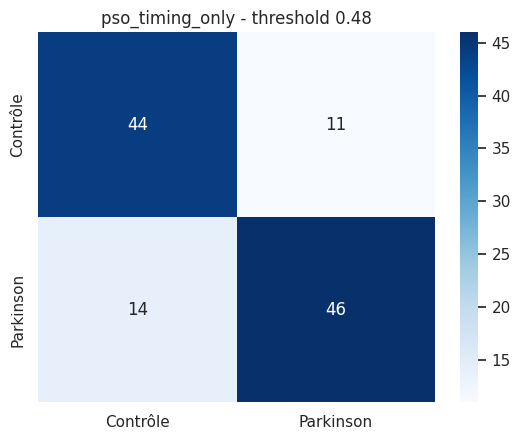

In [10]:
best_name = comparison.iloc[0].experiment
best_features = next(experiment["features"] for experiment in experiments if experiment["name"] == best_name)
best_result, best_oof = eval_segment_aggregated(best_features, return_oof=True)

threshold_rows = []
for threshold in np.linspace(0.2, 0.8, 61):
    pred = (best_oof.proba_mean >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "f1_macro": f1_score(best_oof.label, pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(best_oof.label, pred),
        "accuracy": accuracy_score(best_oof.label, pred),
    })
threshold_df = pd.DataFrame(threshold_rows)
best_threshold = threshold_df.sort_values("f1_macro", ascending=False).iloc[0]
print("best experiment", best_name)
print("chosen threshold", best_threshold.threshold)
display(threshold_df.sort_values("f1_macro", ascending=False).head().round(3))

pred = (best_oof.proba_mean >= best_threshold.threshold).astype(int)
print(classification_report(best_oof.label, pred, target_names=["Contrôle", "Parkinson"]))
cm = confusion_matrix(best_oof.label, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Contrôle", "Parkinson"], yticklabels=["Contrôle", "Parkinson"])
plt.title(f"{best_name} - threshold {best_threshold.threshold:.2f}")
plt.show()


## 9. Export optionnel

Par sécurité, ce notebook n'écrase pas le modèle utilisé par l'application.

Si une variante PSO est retenue, passer `SAVE_SELECTED_MODEL = True` pour exporter un nouvel artefact sous un nouveau nom. On pourra ensuite décider explicitement de l'utiliser dans `src/modalities/keyboard/predictor.py`.


In [11]:
SAVE_SELECTED_MODEL = False

if SAVE_SELECTED_MODEL:
    final_model = make_pipeline()
    final_model.fit(segment_features[best_features], segment_features.label.astype(int))
    artifact = {
        "pipeline": final_model,
        "features": best_features,
        "model": "HistGB",
        "level": "segment_mean_agg",
        "threshold": float(best_threshold.threshold),
        "note": f"NeuroQWERTY v2 PSO experiment; selected={best_name}; grouped CV by pID.",
    }
    path = MODEL_DIR / f"keyboard_dynamics_neuroqwerty_v2_{best_name}.joblib"
    joblib.dump(artifact, path)
    print(path)
else:
    print("No model exported. Set SAVE_SELECTED_MODEL=True after reviewing the comparison.")


No model exported. Set SAVE_SELECTED_MODEL=True after reviewing the comparison.


## 10. Conclusion

Sur cette exécution, la meilleure variante est **PSO timing-only**.

Résultats moyens en validation groupée par sujet, avec segments complets de 300 frappes :

| Variante | Features | F1 macro moyen | Balanced accuracy moyenne | Accuracy moyenne |
|---|---:|---:|---:|---:|
| PSO timing-only | 14 | 0.782 | 0.784 | 0.783 |
| PSO all features | 11 | 0.763 | 0.764 | 0.766 |
| Timing-only | 24 | 0.746 | 0.748 | 0.748 |
| All features | 29 | 0.735 | 0.738 | 0.739 |

Le meilleur seuil exploratoire pour `PSO timing-only` est autour de **0.48-0.51**, avec un F1 macro autour de **0.783**.

Features retenues par `PSO timing-only` :

```text
duration_sec
mean_hold
std_hold
median_hold
iqr_hold
q10_hold
q90_hold
kurt_hold
cv_hold
mean_flight
std_flight
q90_flight
skew_flight
kurt_flight
```

Interprétation :

- retirer manuellement les features dépendantes du layout ne dégrade pas les performances dans cette configuration stricte;
- PSO améliore nettement la variante timing-only tout en réduisant le nombre de features;
- la meilleure variante n’utilise pas `left_rate`, `right_rate`, `hand_switch_rate` ou `hand_entropy`, ce qui est encourageant pour une future version plus robuste entre QWERTY et AZERTY;
- le modèle actuellement utilisé par l’application n’a pas été remplacé automatiquement. Il faut décider explicitement si on veut exporter et brancher cette variante.

Limite importante : cette sélection PSO reste exploratoire. Une validation encore plus stricte demanderait une sélection imbriquée dans chaque fold externe.
